In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')

# The axis labels below use the book's molar underbar, \underline{V}. With no LaTeX
# installed, matplotlib renders math with its own mathtext engine, which only learned
# \underline in 3.11 -- and Colab still ships 3.10. This upgrades it there, and does
# nothing at all on a machine that already has 3.11 or newer.
#
# ON COLAB THIS NEEDS A SESSION RESTART. Colab imports matplotlib as the session
# starts, so pip can replace the files on disk but not the module already loaded in
# memory: without a restart the kernel keeps running 3.10 and the labels still fail.
# One click, once per session. The cell prints the instruction when it applies.
from importlib.metadata import version

if tuple(map(int, version("matplotlib").split(".")[:2])) < (3, 11):
    !pip install -q "matplotlib>=3.11"
    if "matplotlib" in sys.modules:
        print("\n" + "=" * 72)
        print("  matplotlib was upgraded so this notebook can draw the book's notation.")
        print("  RESTART NOW:   Runtime > Restart session,   then Run all.")
        print("  Colab only, once per session. Without it the next figure will fail.")
        print("=" * 72 + "\n")
# ---------------------------------------------------------------------------


# Figure 10.2-6 &mdash; excess properties from the temperature dependence of $\underline{G}^{\rm ex}$

**Figure 10.2-6**, for benzene / 2,2,4-trimethyl pentane at 40 °C: the excess Gibbs
energy, the excess enthalpy and the excess entropy, all three against composition.

Only one of those three is measured. $\underline{G}^{\rm ex}$ comes straight out of a
vapor-liquid equilibrium measurement, one value per data point, as Illustration 10.2-4
does at 55 °C. $\underline{H}^{\rm ex}$ does not: by Eq. 10.2-11 it comes from the
**temperature derivative**

$$\underline{H}^{\rm ex} = -T^2\left[\frac{\partial(\underline{G}^{\rm ex}/T)}{\partial T}\right]_{P,x}
  \qquad\text{equivalently}\qquad
  \underline{S}^{\rm ex} = -\left[\frac{\partial \underline{G}^{\rm ex}}{\partial T}\right]_{P,x}$$

so it needs measurements at *several* temperatures and a differentiation of the data
between them. The chapter says so, and adds a warning: *"One would expect the accuracy
of these results to be less than that of $\underline{G}^{\rm ex}$ since these
calculations involve a differentiation of the experimental data."*

**That warning is the subject of this notebook.** The differentiation is carried out
here from the raw isotherms, and the loss of accuracy is measured rather than asserted:
scatter that is 0.2 % of $\underline{G}^{\rm ex}$ becomes 4 % of
$\underline{H}^{\rm ex}$ and 6 % of $\underline{S}^{\rm ex}$.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from thermo.activity_models import RedlichKisterGex
from thermo.charts import use_book_style
use_book_style()

CAL = 4.184          # J per thermochemical calorie -- the paper works in cal/mol
MMHG = 1.333e-3      # bar per mm Hg, the four-figure factor the chapter itself uses

## The measurements

S. Weissman and S. E. Wood, *Vapor-Liquid Equilibrium of Benzene-2,2,4-Trimethylpentane
Mixtures*, **J. Chem. Phys. 32**, 1153 (1960) &mdash; the chapter's own footnote 4.
They measured at 10 degree intervals from 35 to 75 °C over the whole composition range,
which is what makes the temperature derivative available at all.

Three of their tables are carried below, in their own units:

* **Table I** &mdash; the pure-component vapor pressures at the five temperatures, mm Hg.
* **Table II** &mdash; every equilibrium point: $x_1$, $y_1$, $P$, and the excess Gibbs
  energy $\Delta\underline{G}_p^{\rm E}$ they computed from it. Benzene is species 1.
* **Table III** &mdash; the second virial coefficients used in that computation.

**Three of the 34 points are flagged `used=False`.** Weissman and Wood printed those
in parentheses and say in terms that they are *"quantities which were not used in the
determination of the thermodynamic functions nor in the smoothing process because the
deviations of these quantities from the smoothed values appeared to be quite large."*
Reproducing their analysis means dropping them too, and the flag is carried in the data
rather than applied by deleting rows, so the exclusion is visible.

In [3]:
# Table I -- vapor pressures of the pure components, mm Hg
PVAP = {35: (148.28, 78.24), 45: (223.50, 119.80), 55: (327.05, 178.08),
        65: (466.10, 256.87), 75: (648.17, 361.89)}          # (benzene, isooctane)

# Table III -- second virial coefficients, cm^3/mol, and delta = 2 B12 - B11 - B22
VIRIAL = {35: (-1281., -2182., -1671., 121.), 45: (-1198., -2039., -1562., 114.),
          55: (-1122., -1910., -1463., 106.), 65: (-1053., -1791., -1372., 100.),
          75: (-989., -1683., -1289., 94.)}

# Table II -- x1, y1, P (mm Hg), dG_p^E (cal/mol), used?
#   Benzene is species 1.  used=False marks the parenthesized rows.
TABLE_II = {
    35: [(0.0886, 0.2137,  91.20, 23.9, True), (0.1601, 0.3382, 100.62, 41.1, True),
         (0.3343, 0.5463, 120.23, 74.9, True), (0.4343, 0.6242, 127.84, 83.9, False),
         (0.5061, 0.6731, 133.58, 91.4, True), (0.8375, 0.8640, 148.18, 60.4, True),
         (0.9884, 0.9865, 148.62,  5.7, True)],
    45: [(0.0793, 0.1894, 136.44, 20.1, True), (0.1836, 0.3643, 156.19, 42.6, True),
         (0.3358, 0.5364, 179.71, 70.4, True), (0.3574, 0.5558, 182.66, 73.4, True),
         (0.5125, 0.6738, 200.62, 86.6, True), (0.5512, 0.6998, 204.21, 86.9, True),
         (0.8425, 0.8691, 222.71, 57.0, True), (0.9880, 0.9865, 223.89,  5.7, True)],
    55: [(0.0819, 0.1869, 201.74, 19.9, True), (0.2192, 0.4065, 236.86, 46.3, True),
         (0.3584, 0.5509, 266.04, 68.8, True), (0.3831, 0.5748, 270.73, 70.8, True),
         (0.5256, 0.6786, 293.36, 82.0, True), (0.5924, 0.7293, 302.07, 79.1, False),
         (0.8478, 0.8741, 324.66, 52.5, True), (0.9872, 0.9863, 327.39,  5.6, True)],
    65: [(0.2230, 0.4033, 338.62, 44.6, True), (0.3981, 0.5799, 387.86, 69.2, True),
         (0.5460, 0.6882, 419.95, 78.6, True), (0.6060, 0.7387, 430.65, 73.4, True),
         (0.8548, 0.8806, 461.65, 48.1, True)],
    75: [(0.0879, 0.1870, 407.61, 18.6, True), (0.3862, 0.5636, 533.66, 64.9, True),
         (0.5558, 0.6923, 584.27, 74.8, True), (0.6673, 0.7670, 610.11, 71.0, False),
         (0.8590, 0.8857, 640.86, 44.8, True), (0.9875, 0.9872, 648.69,  5.4, True)],
}

def isotherm(t):
    """x1 and dG_p^E (cal/mol) at t degC, the retained points only."""
    r = [row for row in TABLE_II[t] if row[4]]
    return np.array([q[0] for q in r]), np.array([q[3] for q in r])

n_all = sum(len(v) for v in TABLE_II.values())
n_use = sum(1 for v in TABLE_II.values() for r in v if r[4])
print(f"Table II: {n_all} measured points, {n_use} retained, {n_all - n_use} set aside by the authors")

Table II: 34 measured points, 31 retained, 3 set aside by the authors


### The 55 °C isotherm *is* Illustration 10.2-4

Before differentiating anything, one check that costs nothing and settles the
provenance of a whole illustration. Illustration 10.2-4 prints seven points at 55 °C
with no table number attached. They are Table II's 55 °C rows &mdash; the retained ones,
the parenthesized point dropped &mdash; converted with the chapter's own four-figure
factor, 1 mm Hg = 1.333 × 10⁻³ bar.

That is the **same rounded factor** the chapter uses on Eng and Sandler's data in
Illustration 10.2-5, and it is not the exact 1.333224 × 10⁻³. Using the exact value
would not reproduce the printed digits.

In [4]:
x55, _ = isotherm(55)
P55 = np.array([r[2] for r in TABLE_II[55] if r[4]])
book_x = np.array([0.0819, 0.2192, 0.3584, 0.3831, 0.5256, 0.8478, 0.9872])
book_P = np.array([0.26892, 0.31573, 0.35463, 0.36088, 0.39105, 0.43277, 0.43641])

print("  x_B      P from Table II (bar)    as printed in Illustration 10.2-4")
for xi, pi, bx, bp in zip(x55, P55 * MMHG, book_x, book_P):
    print(f"  {xi:.4f}   {pi:.5f}                {bp:.5f}    "
          f"{'exact' if abs(pi - bp) < 5e-6 and xi == bx else 'DIFFERS'}")
for name, mm, printed in (("benzene  ", PVAP[55][0], 0.43596),
                          ("isooctane", PVAP[55][1], 0.23738)):
    print(f"  P_vap {name} {mm} mm Hg -> {mm * MMHG:.5f} bar    printed {printed:.5f}")

  x_B      P from Table II (bar)    as printed in Illustration 10.2-4
  0.0819   0.26892                0.26892    exact
  0.2192   0.31573                0.31573    exact
  0.3584   0.35463                0.35463    exact
  0.3831   0.36088                0.36088    exact
  0.5256   0.39105                0.39105    exact
  0.8478   0.43277                0.43277    exact
  0.9872   0.43641                0.43641    exact
  P_vap benzene   327.05 mm Hg -> 0.43596 bar    printed 0.43596
  P_vap isooctane 178.08 mm Hg -> 0.23738 bar    printed 0.23738


All nine numbers reproduce exactly. Illustration 10.2-4 is Weissman and Wood's
Tables I and II at 55 °C and nothing else, which means the seven points that Chapter 9
fits four figures to are traceable to a 1960 measurement, row by row.

**One difference, which a later cell needs.** The illustration
computes $\underline{G}^{\rm ex}$ from those pressures assuming an **ideal vapor**;
Weissman and Wood's own $\Delta\underline{G}_p^{\rm E}$ column carries a second-virial
correction and a correction to a 1 atm reference (their Eq. 2). The two columns differ
by about 2 %, systematically. The $\underline{G}^{\rm ex}$ differentiated below is
theirs, corrections included &mdash; it has to be, because their five isotherms are what
the derivative is taken across.

## Step 1 &mdash; one Redlich-Kister fit per isotherm

Eq. 9.5-6, three terms, exactly as in Illustration 10.2-4:

$$\underline{G}^{\rm ex} = x_1x_2\left[a + b(x_1-x_2) + c(x_1-x_2)^2\right]$$

Fitted independently at each of the five temperatures. This is the step that turns a
handful of scattered points at one temperature into a curve that can be evaluated at
any composition &mdash; which is what makes the *next* step, differentiating with
respect to temperature at fixed composition, possible at all.

In [5]:
TEMPS = sorted(TABLE_II)
coef = {}
print("  t (C)   n       a         b         c     (cal/mol)")
for t in TEMPS:
    x, g = isotherm(t)
    coef[t] = RedlichKisterGex.fit_gex(x, g, order=2).a
    print(f"   {t:2d}     {len(x)}   {coef[t][0]:8.2f}  {coef[t][1]:8.2f}  {coef[t][2]:8.2f}")

  t (C)   n       a         b         c     (cal/mol)
   35     6     365.63    100.62     21.23
   45     8     343.99    103.05     26.23
   55     7     323.37    102.09     26.47
   65     5     300.56     87.61     33.20
   75     5     292.89     91.24     22.64


## Step 2 &mdash; the coefficients against temperature

Weissman and Wood then fitted each coefficient to a function of temperature: $a$ and
$b$ quadratic, $c$ linear. Their published result, Eqs. (8) to (10), in cal/mol with
$T$ in K:

$$a = 2428.10 - 10.9940\,T + 0.013961\,T^2 \qquad
  b = -1113.1 + 7.662\,T - 0.01207\,T^2 \qquad
  c = 33 - 0.027\,T$$

**The 65 °C isotherm is excluded from this fit, and the authors say why:** *"The
data at 65° were not used in these calculations because only four points were obtained
which were thought to be reliable. It was possible to fit Eq. (7) to these four points,
but the values of the coefficients deviated markedly from the curve obtained by plotting
the values of the other coefficients against the temperature."* Their own consistency
figures are quoted at 35, 45, 55 and 75 only. Reproducing their smoothing means leaving
65 °C out, and the cell below does.

In [6]:
FIT_T = [35, 45, 55, 75]                       # 65 C excluded, as the authors did
Tk = np.array(FIT_T, float) + 273.15
A = np.polyfit(Tk, [coef[t][0] for t in FIT_T], 2)
B = np.polyfit(Tk, [coef[t][1] for t in FIT_T], 2)
Cc = np.polyfit(Tk, [coef[t][2] for t in FIT_T], 1)

# Weissman and Wood's published Eqs. (8) to (10), same polynomial convention
A_ww, B_ww, C_ww = [0.013961, -10.9940, 2428.10], [-0.01207, 7.662, -1113.1], [-0.027, 33.0]

print("                  constant        T          T^2")
for nm, ours, theirs in (("a", A, A_ww), ("b", B, B_ww), ("c", Cc, C_ww)):
    o, p = list(ours[::-1]) + [0], list(theirs[::-1]) + [0]
    print(f"  {nm}  ours    {o[0]:10.2f} {o[1]:10.4f} {o[2]:12.6f}")
    print(f"     W&W     {p[0]:10.2f} {p[1]:10.4f} {p[2]:12.6f}")

print("\n  ...but what matters is the VALUE at 40 C, not the coefficients:")
T40 = 313.15
print(f"        a         b         c      (cal/mol)")
print(f"  ours  {np.polyval(A, T40):8.2f}  {np.polyval(B, T40):8.2f}  {np.polyval(Cc, T40):8.2f}")
print(f"  W&W   {np.polyval(A_ww, T40):8.2f}  {np.polyval(B_ww, T40):8.2f}  {np.polyval(C_ww, T40):8.2f}")

                  constant        T          T^2
  a  ours       2413.75   -10.9122     0.013845
     W&W        2428.10   -10.9940     0.013961
  b  ours      -1494.16     9.9648    -0.015542
     W&W       -1113.10     7.6620    -0.012070
  c  ours         21.43     0.0083     0.000000
     W&W          33.00    -0.0270     0.000000

  ...but what matters is the VALUE at 40 C, not the coefficients:
        a         b         c      (cal/mol)
  ours    354.29    102.19     24.04
  W&W     354.39    102.64     24.54


### Read that table the right way round

The individual polynomial coefficients look alarming &mdash; our $b$ has a constant term
of about $-1494$ against their $-1113$, and our $c$ even has the opposite slope. **That
is not a disagreement about the data.** A quadratic through four points spanning 40 K,
fitted in $T$ rather than in $(T - T_{\rm ref})$, is badly conditioned: the three terms
are each of order $10^3$ cal/mol and very nearly cancel, so a shift of a fraction of a
calorie in one isotherm's coefficient moves the polynomial's constant term by hundreds.

The quantity with physical meaning is the **value** of $a$, $b$, $c$ at the temperature
of interest, and those agree to better than 0.5 %. Comparing fitted polynomial
coefficients rather than the function they describe is one of the easier ways to
manufacture a discrepancy that is not there.

## Step 3 &mdash; the differentiation

With $a(T)$, $b(T)$, $c(T)$ in hand, Eq. 10.2-8 and Eq. 10.2-11 are now analytic:

$$\underline{S}^{\rm ex} = -\left(\frac{\partial\underline{G}^{\rm ex}}{\partial T}\right)_{P,x}
   = -x_1x_2\left[a'(T) + b'(T)(x_1-x_2) + c'(T)(x_1-x_2)^2\right]
  \qquad
  \underline{H}^{\rm ex} = \underline{G}^{\rm ex} + T\underline{S}^{\rm ex}$$

Note what has happened: the *derivative of the smoothing* has silently replaced the
*derivative of the data*. Nothing was measured between 45 and 55 °C; the quadratic in
$T$ supplies it. Everything downstream inherits whatever that quadratic gets wrong,
which is what Step 4 measures.

In [7]:
def excess(x, T, a_poly, b_poly, c_poly):
    """G^ex, S^ex, H^ex in cal/mol and cal/(mol K) from a Redlich-Kister coefficient
    set expressed as polynomials in T."""
    x = np.asarray(x, float)
    u, xx = 2 * x - 1, x * (1 - x)
    a, b, c = (np.polyval(p, T) for p in (a_poly, b_poly, c_poly))
    da, db, dc = (np.polyval(np.polyder(p), T) for p in (a_poly, b_poly, c_poly))
    g = xx * (a + b * u + c * u**2)
    s = -xx * (da + db * u + dc * u**2)
    return g, s, g + T * s

# Their Table V, 40 C block: x1, dG_p^E, dS_p^E, dH_p^M
TABLE_V_40 = [(0.1, 25.9, 0.212, 92), (0.2, 48.3, 0.372, 165), (0.3, 66.6, 0.482, 218),
              (0.4, 80.3, 0.545, 251), (0.5, 88.6, 0.563, 265), (0.6, 90.2, 0.535, 258),
              (0.7, 83.9, 0.465, 229), (0.8, 68.0, 0.352, 178), (0.9, 40.7, 0.197, 102)]

xv = np.array([r[0] for r in TABLE_V_40])
g_ww, s_ww, h_ww = excess(xv, T40, A_ww, B_ww, C_ww)     # their Eqs. (8)-(10)
g_us, s_us, h_us = excess(xv, T40, A, B, Cc)             # our chain, from Table II

print("  Eqs. (8)-(10) evaluated at 40 C against their own Table V")
print("   x     G calc / table      S calc / table       H calc / table")
exact = 0
for (x, G, S, H), g, s, h in zip(TABLE_V_40, g_ww, s_ww, h_ww):
    marks = []
    for calc, printed, places in ((g, G, 1), (s, S, 3), (h, H, 0)):
        ok = abs(calc - printed) <= 0.5 * 10.0**-places + 1e-9
        exact += ok
        marks.append(" " if ok else "*")
    print(f"  {x:.1f}   {g:6.2f} /{marks[0]}{G:5.1f}      {s:.4f} /{marks[1]}{S:.3f}"
          f"      {h:6.1f} /{marks[2]}{H:3d}")
print(f"\n  {exact} of 27 land on the printed digit; {27 - exact} marked * are one in the")
print("  last place away, which is what the authors' own footnote 20 allows: they set")
print("  the significant figures in Eqs. (8)-(10) to give G^ex 'to 0.1 cal per mole'.")

  Eqs. (8)-(10) evaluated at 40 C against their own Table V
   x     G calc / table      S calc / table       H calc / table
  0.1    25.92 /  25.9      0.2115 /*0.212        92.1 /  92
  0.2    48.26 /  48.3      0.3714 /*0.372       164.6 / 165
  0.3    66.62 /  66.6      0.4821 / 0.482       217.6 / 218
  0.4    80.36 /* 80.3      0.5452 / 0.545       251.1 / 251
  0.5    88.60 /  88.6      0.5626 / 0.563       264.8 / 265
  0.6    90.21 /  90.2      0.5354 / 0.535       257.9 / 258
  0.7    83.87 /  83.9      0.4648 / 0.465       229.4 / 229
  0.8    67.97 /  68.0      0.3517 / 0.352       178.1 / 178
  0.9    40.70 /  40.7      0.1967 / 0.197       102.3 / 102

  24 of 27 land on the printed digit; 3 marked * are one in the
  last place away, which is what the authors' own footnote 20 allows: they set
  the significant figures in Eqs. (8)-(10) to give G^ex 'to 0.1 cal per mole'.


Eqs. (8) to (10) are the smoothing behind Table V, so the curves in the print figure
below are Weissman and Wood's own results, evaluated rather than traced. The three starred
values are not a disagreement &mdash; the largest is 0.06 cal/mol, inside the 0.1 cal/mol
the authors claim for their own equations.

**Their 70 °C block has one arithmetic fault**, found the same way and reported here
because it is in a table a reader might use: at $x_1 = 0.7$ the row is
$\underline{G}^{\rm ex} = 71.7$, $\underline{S}^{\rm ex} = 0.349$,
$\underline{H}^{\rm ex} = 190$ &mdash; but $\underline{G}^{\rm ex} + T\underline{S}^{\rm ex}
= 71.7 + 343.15 \times 0.349 = 191.5$, and Eqs. (8) to (10) give 191.7. The row fails
the table's own identity; 190 should read 192. It does not touch Figure 10.2-6, which is
the 40 °C block, and the other 53 values in Table V are right.

## Step 4 &mdash; what the differentiation costs

Two independent measurements of the same thing.

**First**, our chain against theirs. Both start from Table II; ours refits every
isotherm and every temperature dependence from scratch.

In [8]:
xg = np.linspace(1e-9, 1 - 1e-9, 401)
G1, S1, H1 = excess(xg, T40, A_ww, B_ww, C_ww)
G2, S2, H2 = excess(xg, T40, A, B, Cc)
for nm, u, v in (("G^ex", G1, G2), ("H^ex", H1, H2), ("S^ex", S1, S2)):
    m = np.abs(u) > 1e-6
    print(f"  {nm}   largest difference {np.max(np.abs(u - v)[m]):7.3f}   "
          f"({100 * np.max(np.abs((u - v)[m] / u[m])):.1f} % of the local value)")

  G^ex   largest difference   0.087   (0.2 % of the local value)
  H^ex   largest difference   5.043   (4.7 % of the local value)
  S^ex   largest difference   0.016   (7.9 % of the local value)


$\underline{G}^{\rm ex}$ agrees to a tenth of a percent; $\underline{H}^{\rm ex}$ and
$\underline{S}^{\rm ex}$, from the same data by the same method, agree only to a few
percent. Two competent smoothings of one data set differ thirty times more in the
derived property than in the measured one.

**Second**, and more directly: Weissman and Wood state the root-mean-square deviation of
their smoothed $\underline{G}^{\rm ex}$ from the measurements as **±0.4 cal per mole**.
Perturb Table II by exactly that much and push the noise through the whole chain.

In [9]:
rng = np.random.default_rng(0)
xs = np.array([0.3, 0.5, 0.7])
base = excess(xs, T40, A, B, Cc)

trials = []
for _ in range(2000):
    cf = {}
    for t in TEMPS:
        x, g = isotherm(t)
        cf[t] = RedlichKisterGex.fit_gex(x, g + rng.normal(0, 0.4, g.size), order=2).a
    Ap = np.polyfit(Tk, [cf[t][0] for t in FIT_T], 2)
    Bp = np.polyfit(Tk, [cf[t][1] for t in FIT_T], 2)
    Cp = np.polyfit(Tk, [cf[t][2] for t in FIT_T], 1)
    trials.append(excess(xs, T40, Ap, Bp, Cp))
tr = np.array(trials)                                    # (2000, 3 properties, 3 compositions)

print("  +-0.4 cal/mol of scatter on the MEASURED G^ex, propagated to 40 C:\n")
print("   x        G^ex                 S^ex                  H^ex")
for j, x in enumerate(xs):
    out = []
    for i, val in enumerate(base):
        sd = tr[:, i, j].std()
        out.append(f"{val[j]:7.2f} +- {sd:.2f} ({100 * sd / val[j]:.1f} %)")
    print(f"  {x:.1f}   " + "   ".join(out))

  +-0.4 cal/mol of scatter on the MEASURED G^ex, propagated to 40 C:

   x        G^ex                 S^ex                  H^ex
  0.3     66.62 +- 0.16 (0.2 %)      0.49 +- 0.03 (5.6 %)    219.97 +- 8.63 (3.9 %)
  0.5     88.57 +- 0.21 (0.2 %)      0.56 +- 0.03 (5.2 %)    264.01 +- 9.30 (3.5 %)


  0.7     83.79 +- 0.23 (0.3 %)      0.45 +- 0.04 (7.8 %)    225.01 +- 11.12 (4.9 %)


### The chapter's warning, with a number on it

Scatter worth **0.2 %** of the measured excess Gibbs energy becomes **4 to 5 %** of the
excess enthalpy and **5 to 8 %** of the excess entropy. The arithmetic is not subtle:
$\underline{H}^{\rm ex} = \underline{G}^{\rm ex} + T\underline{S}^{\rm ex}$, so an
uncertainty of 0.03 cal/(mol K) in the derivative arrives in the enthalpy multiplied by
$T$ &mdash; $313 \times 0.03 \approx 9$ cal/mol, which is what the table reports. A
differentiation does not preserve the accuracy of what it acts on, and multiplying the
result by an absolute temperature does not help.

**This also settles the first comparison.** Our chain and theirs differ by up to 5
cal/mol in $\underline{H}^{\rm ex}$ &mdash; well inside the ±9 to ±11 cal/mol that the
data's own scatter produces. The two smoothings are not in disagreement; they are two
draws from the same uncertainty, and neither is the right one to a precision the
measurements do not support.

**So the figure below is drawn from Eqs. (8) to (10)** &mdash; Weissman and Wood's
published smoothing, which reproduces their Table V exactly. The chapter says the figure
shows *"the results of their calculations,"* and that is what those equations are. The
independent chain above is the check that the calculation is understood, not a
competitor to it; refitting to three significant figures a quantity whose uncertainty
is 4 % would be the wrong lesson.

## The figure

  maxima:  G^ex  378.7 J/mol at x_B = 0.573
           H^ex 1109.0 J/mol at x_B = 0.517
           S^ex  2.355 J/(mol K) at x_B = 0.487


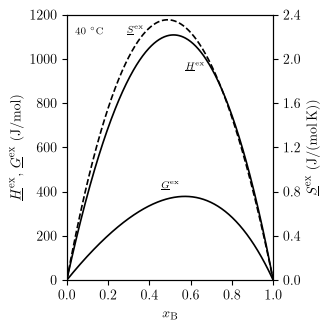

In [10]:
xg = np.linspace(0.0, 1.0, 401)
g, s, h = excess(xg, T40, A_ww, B_ww, C_ww)
gJ, hJ = g * CAL, h * CAL                    # J/mol
sJ = s * CAL                                 # J/(mol K)

SCALE = 500.0                                # J/mol per J/(mol K) -- the printed 1200:2.4

fig, ax = plt.subplots(figsize=(3.4, 3.4))
ax.plot(xg, hJ, "-", color="k", lw=1.2)
ax.plot(xg, gJ, "-", color="k", lw=1.2)
ax.plot(xg, sJ * SCALE, "--", color="k", lw=1.2)

ax.set_xlabel(r"$x_{\rm B}$")
ax.set_ylabel(r"$\underline{H}^{\rm ex}$, $\underline{G}^{\rm ex}$ (J/mol)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1200)

axr = ax.twinx()
axr.set_ylim(0, 1200 / SCALE)
axr.set_ylabel(r"$\underline{S}^{\rm ex}$ (J/(mol$\,$K))")

from matplotlib.ticker import MultipleLocator
ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_major_locator(MultipleLocator(200))
axr.yaxis.set_major_locator(MultipleLocator(0.4))

ax.text(0.33, np.interp(0.33, xg, sJ * SCALE) + 60, r"$\underline{S}^{\rm ex}$",
        fontsize=7, ha="center")
ax.text(0.62, np.interp(0.62, xg, hJ) - 110, r"$\underline{H}^{\rm ex}$",
        fontsize=7, ha="center")
ax.text(0.50, np.interp(0.50, xg, gJ) + 45, r"$\underline{G}^{\rm ex}$",
        fontsize=7, ha="center")
ax.text(0.04, 0.955, r"40 $^\circ$C", transform=ax.transAxes, fontsize=7, va="top")
fig.tight_layout()

print(f"  maxima:  G^ex {gJ.max():6.1f} J/mol at x_B = {xg[gJ.argmax()]:.3f}")
print(f"           H^ex {hJ.max():6.1f} J/mol at x_B = {xg[hJ.argmax()]:.3f}")
print(f"           S^ex {sJ.max():6.3f} J/(mol K) at x_B = {xg[sJ.argmax()]:.3f}")

**Three things the figure shows that the numbers alone do not.**

All three functions are **positive across the whole range**. Positive
$\underline{H}^{\rm ex}$ means mixing is endothermic &mdash; benzene-isooctane contacts
are less favorable than the average of the like contacts. Positive
$\underline{S}^{\rm ex}$ means the mixture is *more* disordered than an ideal solution
of the same composition, which is the orientation effect the paper was written to look
for: benzene's flat molecules are partly ordered in the pure liquid, and mixing breaks
that ordering up.

$\underline{G}^{\rm ex}$ is **the difference of two larger and nearly cancelling terms**.
At $x_{\rm B} = 0.5$, $\underline{H}^{\rm ex}$ is 1108 J/mol and
$T\underline{S}^{\rm ex}$ is 737, leaving 371 &mdash; a third of either. And it is the
*difference* that the vapor-liquid measurement pins down, not the two terms separately.
That is the whole reason the accuracy runs the way it does in this section: the small
number is the measured one, and the two large ones are inferred from how it changes with
temperature.

The **maxima are at different compositions**: $\underline{H}^{\rm ex}$ and
$\underline{S}^{\rm ex}$ peak near equimolar, $\underline{G}^{\rm ex}$ noticeably
benzene-rich of it. The asymmetry lives almost entirely in $b$, the coefficient
multiplying $(x_1 - x_2)$, and the small shift between the peaks is the temperature
derivative of $b$ &mdash; a second-order feature of the data that the section's
Redlich-Kister expansion happens to capture cleanly.

**Departures from the published art.** The gray panel background is gone
&mdash; the figure is pure black line art like the rest of the chapter. The twin
ordinate is kept, because $\underline{G}^{\rm ex}$ and $\underline{H}^{\rm ex}$ are in
J/mol and $\underline{S}^{\rm ex}$ is in J/(mol K); it is a real change of units, not the
cosmetic one that was removed from Illustration 10.2-4's second figure. The
$\underline{S}^{\rm ex}$ curve is **dashed** to mark which axis it belongs to, since
line style is the only way left to say so once the color is gone.

## Print art

In [11]:
# --- Print art: Figure 10.2-6 ----------------------------------------------
#   pdf/Fig_10.2-6.pdf -> deliverables/figures/print-bw/ch10/c10f018.pdf
#
# c10f018, NOT c10f006: the .docx art slugs restart their numbering per section.
# This is the last figure in Sec. 10.2 that was still on inherited .eps stock.
#
# The curves are Weissman and Wood's Eqs. (8)-(10) at 313.15 K, which reproduce
# all 27 values of their Table V's 40 C block -- see the check above.
import os
os.makedirs("pdf", exist_ok=True)
fig.savefig("pdf/Fig_10.2-6.pdf", dpi=300, bbox_inches="tight")
print("wrote pdf/Fig_10.2-6.pdf")

wrote pdf/Fig_10.2-6.pdf


## Your turn

1. The differentiation above went through a quadratic in $T$ fitted to four isotherms.
   Try it with a **straight line** through the same four, and with a cubic. How much
   does $\underline{H}^{\rm ex}$ at $x_{\rm B} = 0.5$, 40 °C move? Compare the spread
   you get to the ±9 cal/mol the Monte Carlo cell reports, and decide which of the three
   fits the data actually justifies.
2. Weissman and Wood dropped the 65 °C isotherm. Put it back into `FIT_T` and rerun.
   Does $\underline{H}^{\rm ex}$ change by more than the noise? Their stated reason was
   that its coefficients "deviated markedly" &mdash; check that claim against the Step 1
   table, and say whether you would have dropped it.
3. The figure is at 40 °C. Their Table V also gives 70 °C, and their Fig. 4 plots both.
   Draw the pair. All three functions decrease with temperature; which one decreases
   proportionally the most, and what does that say about the orientation effect the
   paper was looking for?
4. Illustration 10.2-4's $\underline{G}^{\rm ex}$ at 55 °C assumes an ideal vapor, while
   the column differentiated here carries the second virial correction of the paper's
   Eq. 2. Using `VIRIAL` above and the pure liquid molar volumes, compute the correction
   at each 55 °C point. How large is it, and would including it visibly change any curve
   in the figure?